In [7]:
#Comments
Data handling → pandas, numpy
Visualization → matplotlib, seaborn
Machine learning → scikit-learn models


------------------
# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Plot styling
plt.style.use("default")
sns.set(style="whitegrid")


In [3]:
import pandas as pd


In [5]:
# Loading the dataset

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.shape


(7043, 21)

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [15]:
#Since the data has string datatype, converting to numeric and droping the 11 rows

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].isna().sum()


11

In [17]:
df = df.dropna(subset=['TotalCharges'])
df.shape


(7032, 21)

In [19]:
df = df.drop(columns=['customerID'])


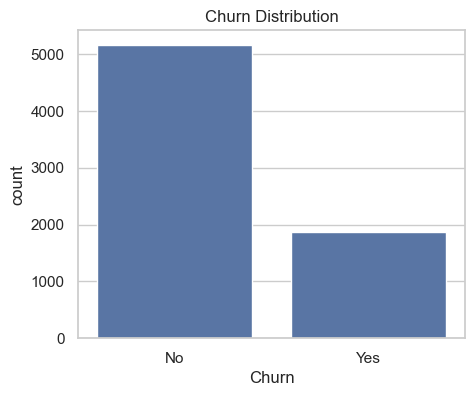

In [21]:
# Beginning Churn distribution

plt.figure(figsize=(5,4))
sns.countplot(x=df['Churn'])
plt.title("Churn Distribution")
plt.show()


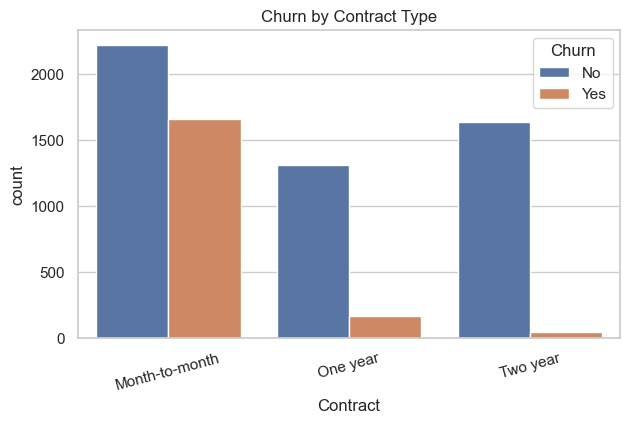

In [23]:
#Doing Churn by Contract Type
#month to month customer will churn more

plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()


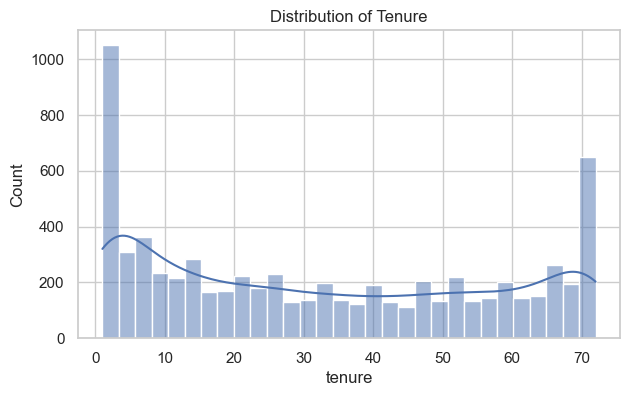

In [25]:
#Tenure Distribution
#people in short tenure will churn more

plt.figure(figsize=(7,4))
sns.histplot(df['tenure'], bins=30, kde=True)
plt.title("Distribution of Tenure")
plt.show()


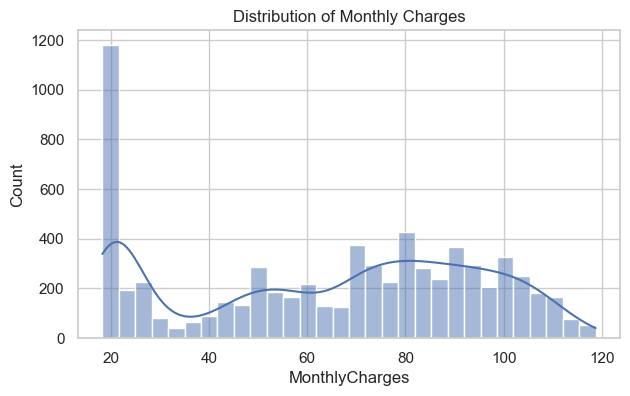

In [27]:
#Monthly Charges distribution
#High bill will make more churn

plt.figure(figsize=(7,4))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)
plt.title("Distribution of Monthly Charges")
plt.show()


In [29]:
#reasons why people churn more is accessed in the above cells

In [31]:
#Beginning to prepare dtaa for machine learning
#as ML models do not undrestand yes/no string texts so converting to numeric

#following code snippets show what is being done in each code:

In [33]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


In [35]:
#converting all text to numeric dummy variable

cat_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)




In [37]:
#defining X n Y

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']


In [39]:
#train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [41]:
#scaling numeic features  for logistic regression 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [43]:
#now running the final code below:


In [67]:
#error fixing
# RELOAD clean dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [69]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])


In [71]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].isna().sum()


0

In [73]:
cat_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)


In [75]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']


In [77]:
y.isna().sum()


0

In [83]:
from sklearn.model_selection import train_test_split

# Correct train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Show shapes so we know it's correct
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((5625, 7061), (1407, 7061), (5625,), (1407,))

In [85]:
# logistic regression model 

In [87]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)


In [89]:
#random forest model

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [91]:
#evaluating logistic regression

print("Logistic Regression Results\n")

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))


Logistic Regression Results

Accuracy: 0.8038379530916845

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Confusion Matrix:
[[916 117]
 [159 215]]


In [93]:
#evaluating random forest 

print("Random Forest Results\n")

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


Random Forest Results

Accuracy: 0.7945984363894811

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.47      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Confusion Matrix:
[[943  90]
 [199 175]]


In [95]:
#ft important random forest 

importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(10)


,feature,importance
3,TotalCharges,0.101946
1,tenure,0.095377
2,MonthlyCharges,0.081450
7041,InternetService_Fiber optic,0.028538
7059,PaymentMethod_Electronic check,0.024252
7056,Contract_Two year,0.024187
7044,OnlineSecurity_Yes,0.020160
7050,TechSupport_Yes,0.019357
7055,Contract_One year,0.018015
7057,PaperlessBilling_Yes,0.017451


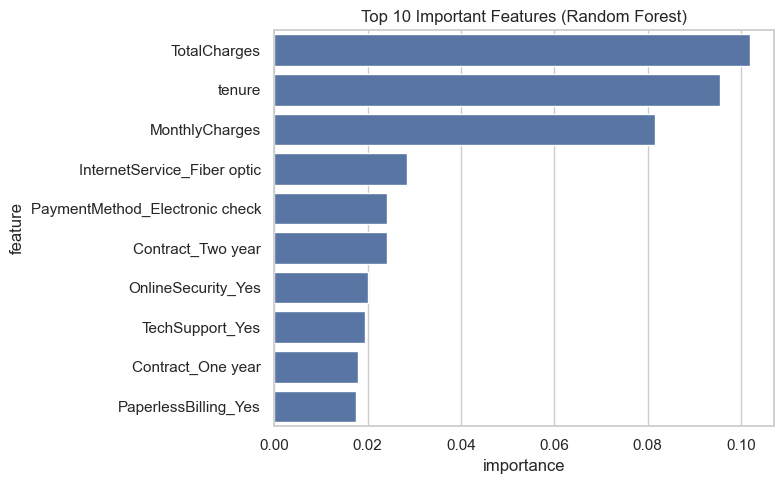

In [97]:
plt.figure(figsize=(8,5))
sns.barplot(data=feat_imp.head(10), x='importance', y='feature')
plt.title("Top 10 Important Features (Random Forest)")
plt.tight_layout()
plt.show()


In [99]:
# done with Logistic Regression
#Random Forest
#Now th evaluation numbers.

In [101]:
# first logostic evaluation

print("Logistic Regression Results\n")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))


Logistic Regression Results

Accuracy: 0.8038379530916845

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Confusion Matrix:
[[916 117]
 [159 215]]


In [103]:
#random forest evaluation

print("Random Forest Results\n")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


Random Forest Results

Accuracy: 0.7945984363894811

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.47      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Confusion Matrix:
[[943  90]
 [199 175]]
